In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/creditcard.csv')

X = df.drop('Class', axis=1) #Drop class column
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
) #stratify makes sure to keep same data split for unbalanced data

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (227845, 30)
Test set: (56962, 30)


In [3]:
#make pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model',LogisticRegression(max_iter=1000, random_state=42))
])

#scaler - make all features same range
#smote = balance training data with smote
#model = trains logistic regression on balanced, scaled data

In [4]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [5]:
#Evaluate
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



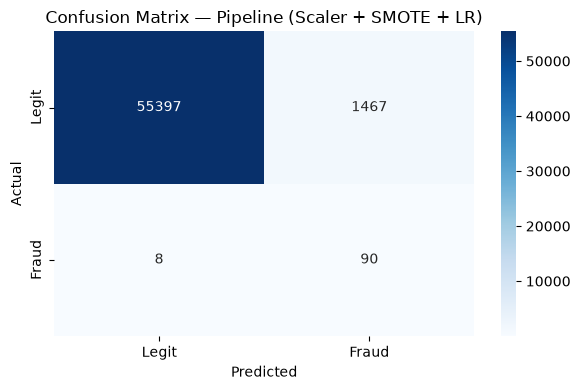

In [6]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix — Pipeline (Scaler + SMOTE + LR)')
plt.tight_layout()
plt.savefig('../notebooks/confusion_matrix_pipeline.png')
plt.show()

In [ ]:
#Confirming pipline steps

print("Pipeline steps:")
for name, step in pipeline.steps:
    print(f"  {name}: {step}")

Pipeline steps:
  scaler: StandardScaler()
  smote: SMOTE(random_state=42)
  model: LogisticRegression(max_iter=1000, random_state=42)
